In [15]:
from utils import add_project_root_to_sys_path
add_project_root_to_sys_path()
from neuralnet.datasets import ParquetDataset
from neuralnet.datasets.ringer import RingerParquetDataset
from neuralnet.plotting import plot_variable_distribution_comparison
from neuralnet.workflows.ringer.training import RingerKerasTrainingJob
from neuralnet.metrics import enhanced_confusion_matrix_from_polars, polars_sp_index
from neuralnet import get_logger
from pathlib import Path
import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use(hep.style.ATLAS)
import polars as pl
import numpy as np
from itertools import product

logger = get_logger()

In [2]:
training_job_dir = Path.home() / 'data' / 'neuralnet_jobs' / 'mlp'
training_job = RingerKerasTrainingJob.load(training_job_dir)
training_job

RingerKerasTrainingJob(batch_size=1024, data_table='electron_ringer', dataset_dir=PosixPath('/home/lucasbanunes/data/ringer-datasets/datasets/mc21_isabela_qt_2sigma_restriction'), et_col='TrigEMClusterContainer.et', et_bins=[Bin(low=15000.0, high=20000.0, closed='left'), Bin(low=20000.0, high=30000.0, closed='left'), Bin(low=30000.0, high=40000.0, closed='left'), Bin(low=40000.0, high=50000.0, closed='left'), Bin(low=50000.0, high=inf, closed='left')], eta_col='TrigEMClusterContainer.eta', eta_bins=[AbsoluteBin(low=0.0, high=0.8, closed='left'), AbsoluteBin(low=0.8, high=1.37, closed='left'), AbsoluteBin(low=1.37, high=1.52, closed='left'), AbsoluteBin(low=1.52, high=2.37, closed='left'), AbsoluteBin(low=2.37, high=2.5, closed='left')], fold_col='kfold', kfold_table='standard_binning_kfold', label_col='label', norm_strategy='l1', rings_col='TrigEMClusterContainer.ringsE', ring_fraction=2, model_factory=MLPFactory(layers=[DenseFactory(units=5, activation='relu', kernel_initializer='glor

In [3]:
training_job.model_factory.name

'mlp_v0'

In [4]:
specialist_committee = training_job.get_specialist_committee()
specialist_committee

2026-08-02 11:54:33.034815: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-08-02 11:54:33.063398: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-02 11:54:34.409120: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-02 11:54:39.166930: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

In [5]:
dataset_types = ['train', 'val', 'test']
references = {
    'tight': {
        'tpr': 0.9,
        'color': 'red',
        'label': 'Tight'
    },
    'medium': {
        'tpr': 0.95,
        'color': 'orange',
        'label': 'Medium'
    },
    'loose': {
        'tpr': 0.99,
        'color': 'green',
        'label': 'Loose'
    }
}


In [6]:
# predictions = []
# for i, specialist_to_evaluate in enumerate(specialist_committee.models):
#     et_bin = specialist_to_evaluate.training_results['et_bin']
#     eta_bin = specialist_to_evaluate.training_results['eta_bin']
#     logger.info(f"{i} - Evaluating model with et bin: {et_bin}, eta bin: {eta_bin}")
#     dataset = training_job.get_dataset(
#         specialist_to_evaluate.training_results['fold'],
#         et_bin=specialist_to_evaluate.training_results['et_bin'],
#         eta_bin=specialist_to_evaluate.training_results['eta_bin']
#     )
#     data_df = dataset.predict_df()
#     logger.info('Predicting on the evaluation dataset...')
#     prediction_df = data_df.pipe(specialist_to_evaluate.predict, passthrough=True)
#     predictions.append(prediction_df)
# prdictions_df = pl.concat(predictions)
# prdictions_df.sink_parquet(
#     pl.PartitionBy(
#         str(dataset.get_table_path(training_job.model_factory.name)),
#         max_rows_per_file=100_000,
#     )
# )

In [7]:
for i, specialist_to_evaluate in enumerate(specialist_committee.models):
    et_bin = specialist_to_evaluate.training_results['et_bin']
    eta_bin = specialist_to_evaluate.training_results['eta_bin']
    logger.info(f"{i} - Evaluating model with et bin: {et_bin}, eta bin: {eta_bin}")
    dataset = training_job.get_dataset(
        specialist_to_evaluate.training_results['fold'],
        et_bin=specialist_to_evaluate.training_results['et_bin'],
        eta_bin=specialist_to_evaluate.training_results['eta_bin']
    )
    data_df = dataset.predict_df()
    logger.info('Predicting on the evaluation dataset...')
    prediction_df = data_df.pipe(specialist_to_evaluate.predict, passthrough=True)
    cm_dfs = []
    for dataset_type in dataset_types:
        logger.info(f"Computing confusion matrix for {dataset_type} dataset...")
        cm_df = enhanced_confusion_matrix_from_polars(
            data=prediction_df.filter(pl.col(f'is_{dataset_type}')),
            score_col='output',
            label_col='label'
        )
        cm_dfs.append(cm_df)
    cm_dfs = pl.collect_all(cm_dfs)
    for dataset_type, cm_df in zip(dataset_types, cm_dfs):
        dataset_type_evaluation_results = {
            'confusion_matrix': cm_df
        }
        for reference_name, reference_info in references.items():
            reference_tpr = reference_info['tpr']
            logger.info(f"Finding threshold for reference TPR of {reference_tpr} in {dataset_type} dataset...")
            reference_tpr_df = (
                cm_df
                .with_columns((pl.col('tpr') - reference_tpr).abs().truediv(reference_tpr).mul(100).alias('relative_tpr_err'))
                .sort("relative_tpr_err")
                .head(5)
            )
            dataset_type_evaluation_results[reference_name] = reference_tpr_df.row(0, named=True)
            dataset_type_evaluation_results[reference_name]['ref'] = reference_info
        specialist_to_evaluate.training_results[dataset_type] = dataset_type_evaluation_results

 [Sun, 02 Aug 2026 11:54:43] INFO 0 - Evaluating model with et bin: {'low': 20000.0, 'high': 30000.0, 'closed': 'left'}, eta bin: {'low': 1.52, 'high': 2.37, 'closed': 'left'}
 [Sun, 02 Aug 2026 11:54:44] INFO Predicting on the evaluation dataset...


6411/6411 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step


 [Sun, 02 Aug 2026 11:55:13] INFO Computing confusion matrix for train dataset...
 [Sun, 02 Aug 2026 11:55:13] INFO Computing confusion matrix for val dataset...
 [Sun, 02 Aug 2026 11:55:13] INFO Computing confusion matrix for test dataset...
 [Sun, 02 Aug 2026 11:55:14] INFO Finding threshold for reference TPR of 0.9 in train dataset...
 [Sun, 02 Aug 2026 11:55:14] INFO Finding threshold for reference TPR of 0.95 in train dataset...
 [Sun, 02 Aug 2026 11:55:14] INFO Finding threshold for reference TPR of 0.99 in train dataset...
 [Sun, 02 Aug 2026 11:55:14] INFO Finding threshold for reference TPR of 0.9 in val dataset...
 [Sun, 02 Aug 2026 11:55:14] INFO Finding threshold for reference TPR of 0.95 in val dataset...
 [Sun, 02 Aug 2026 11:55:14] INFO Finding threshold for reference TPR of 0.99 in val dataset...
 [Sun, 02 Aug 2026 11:55:14] INFO Finding threshold for reference TPR of 0.9 in test dataset...
 [Sun, 02 Aug 2026 11:55:14] INFO Finding threshold for reference TPR of 0.95 in 

5851/5851 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step


 [Sun, 02 Aug 2026 11:55:38] INFO Computing confusion matrix for train dataset...
 [Sun, 02 Aug 2026 11:55:38] INFO Computing confusion matrix for val dataset...
 [Sun, 02 Aug 2026 11:55:38] INFO Computing confusion matrix for test dataset...
 [Sun, 02 Aug 2026 11:55:39] INFO Finding threshold for reference TPR of 0.9 in train dataset...
 [Sun, 02 Aug 2026 11:55:39] INFO Finding threshold for reference TPR of 0.95 in train dataset...
 [Sun, 02 Aug 2026 11:55:39] INFO Finding threshold for reference TPR of 0.99 in train dataset...
 [Sun, 02 Aug 2026 11:55:39] INFO Finding threshold for reference TPR of 0.9 in val dataset...
 [Sun, 02 Aug 2026 11:55:39] INFO Finding threshold for reference TPR of 0.95 in val dataset...
 [Sun, 02 Aug 2026 11:55:39] INFO Finding threshold for reference TPR of 0.99 in val dataset...
 [Sun, 02 Aug 2026 11:55:39] INFO Finding threshold for reference TPR of 0.9 in test dataset...
 [Sun, 02 Aug 2026 11:55:39] INFO Finding threshold for reference TPR of 0.95 in 

...

 [Sun, 02 Aug 2026 12:01:49] INFO Computing confusion matrix for train dataset...
 [Sun, 02 Aug 2026 12:01:49] INFO Computing confusion matrix for val dataset...
 [Sun, 02 Aug 2026 12:01:49] INFO Computing confusion matrix for test dataset...
 [Sun, 02 Aug 2026 12:01:50] INFO Finding threshold for reference TPR of 0.9 in train dataset...
 [Sun, 02 Aug 2026 12:01:50] INFO Finding threshold for reference TPR of 0.95 in train dataset...
 [Sun, 02 Aug 2026 12:01:50] INFO Finding threshold for reference TPR of 0.99 in train dataset...
 [Sun, 02 Aug 2026 12:01:50] INFO Finding threshold for reference TPR of 0.9 in val dataset...
 [Sun, 02 Aug 2026 12:01:50] INFO Finding threshold for reference TPR of 0.95 in val dataset...
 [Sun, 02 Aug 2026 12:01:50] INFO Finding threshold for reference TPR of 0.99 in val dataset...
 [Sun, 02 Aug 2026 12:01:50] INFO Finding threshold for reference TPR of 0.9 in test dataset...
 [Sun, 02 Aug 2026 12:01:50] INFO Finding threshold for reference TPR of 0.95 in 

1257/1257 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


 [Sun, 02 Aug 2026 12:02:00] INFO Computing confusion matrix for train dataset...
 [Sun, 02 Aug 2026 12:02:00] INFO Computing confusion matrix for val dataset...
 [Sun, 02 Aug 2026 12:02:00] INFO Computing confusion matrix for test dataset...
 [Sun, 02 Aug 2026 12:02:01] INFO Finding threshold for reference TPR of 0.9 in train dataset...
 [Sun, 02 Aug 2026 12:02:01] INFO Finding threshold for reference TPR of 0.95 in train dataset...
 [Sun, 02 Aug 2026 12:02:01] INFO Finding threshold for reference TPR of 0.99 in train dataset...
 [Sun, 02 Aug 2026 12:02:01] INFO Finding threshold for reference TPR of 0.9 in val dataset...
 [Sun, 02 Aug 2026 12:02:01] INFO Finding threshold for reference TPR of 0.95 in val dataset...
 [Sun, 02 Aug 2026 12:02:01] INFO Finding threshold for reference TPR of 0.99 in val dataset...
 [Sun, 02 Aug 2026 12:02:01] INFO Finding threshold for reference TPR of 0.9 in test dataset...
 [Sun, 02 Aug 2026 12:02:01] INFO Finding threshold for reference TPR of 0.95 in 

169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


 [Sun, 02 Aug 2026 12:02:05] INFO Computing confusion matrix for train dataset...
 [Sun, 02 Aug 2026 12:02:05] INFO Computing confusion matrix for val dataset...
 [Sun, 02 Aug 2026 12:02:05] INFO Computing confusion matrix for test dataset...
 [Sun, 02 Aug 2026 12:02:07] INFO Finding threshold for reference TPR of 0.9 in train dataset...
 [Sun, 02 Aug 2026 12:02:07] INFO Finding threshold for reference TPR of 0.95 in train dataset...
 [Sun, 02 Aug 2026 12:02:07] INFO Finding threshold for reference TPR of 0.99 in train dataset...
 [Sun, 02 Aug 2026 12:02:07] INFO Finding threshold for reference TPR of 0.9 in val dataset...
 [Sun, 02 Aug 2026 12:02:07] INFO Finding threshold for reference TPR of 0.95 in val dataset...
 [Sun, 02 Aug 2026 12:02:07] INFO Finding threshold for reference TPR of 0.99 in val dataset...
 [Sun, 02 Aug 2026 12:02:07] INFO Finding threshold for reference TPR of 0.9 in test dataset...
 [Sun, 02 Aug 2026 12:02:07] INFO Finding threshold for reference TPR of 0.95 in 

/tmp/ipykernel_796523/4074295573.py:34: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  ax.plot(
/tmp/ipykernel_796523/4074295573.py:38: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ro" (-> color='r'). The keyword argument will take precedence.
  ax_inset.plot(


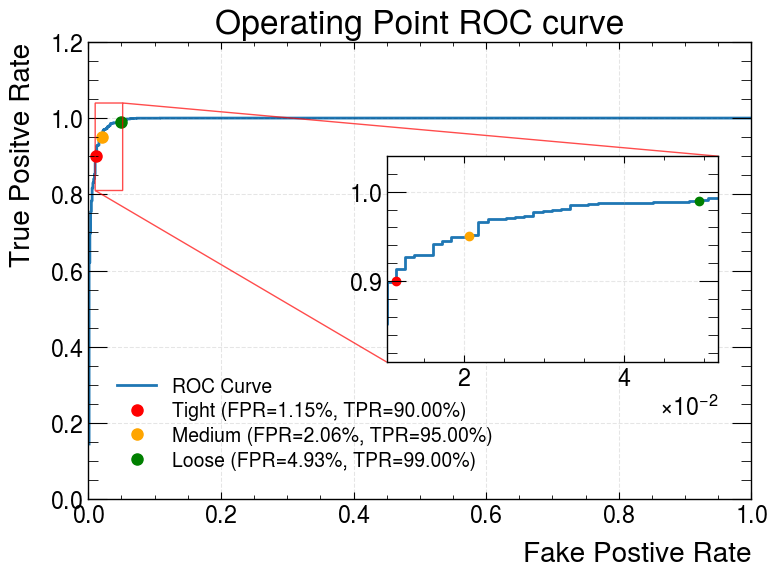

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
confusion_matrix_df = specialist_to_evaluate.training_results['train']['confusion_matrix']
fpr = confusion_matrix_df['fpr'].to_numpy()
tpr = confusion_matrix_df['tpr'].to_numpy()
# ax.grid(linestyle="--", alpha=0.1, color="k")
# ax.plot(fpr, tpr, label='ROC Curve')
# fig.tight_layout()

# 1. Automatically detect the elbow point (maximizing Youden's J statistic: TPR - FPR)
# elbow_idx = np.argmax(tpr - fpr)
# elbow_fpr = fpr[elbow_idx]
# elbow_tpr = tpr[elbow_idx]
# Plot main ROC curve & elbow point
ax.grid(linestyle="--", alpha=0.1, color="k")
ax.plot(fpr, tpr, label='ROC Curve', color='tab:blue')
# ax.plot(elbow_fpr, elbow_tpr, 'ro', label=f'Elbow (FPR={elbow_fpr:.3f}, TPR={elbow_tpr:.3f})')
# 2. Add floating inset axis [x_origin, y_origin, width, height] in axes fraction coords
# Placed in the lower-right area to avoid covering the upper-left ROC curve
ax_inset = ax.inset_axes([0.45, 0.3, 0.5, 0.45])
# Plot ROC curve and elbow on the inset axis
ax_inset.plot(fpr, tpr, color='tab:blue')
# ax_inset.plot(elbow_fpr, elbow_tpr, 'ro', markersize=6)
ax_inset.grid(linestyle="--", alpha=0.3)
ref_tprs = []
ref_fprs = []
for ref, ref_info in references.items():
    ref_result = specialist_to_evaluate.training_results['train'][ref]
    ref_tpr = ref_result['tpr']
    ref_tprs.append(ref_tpr)
    ref_fpr = ref_result['fpr']
    ref_fprs.append(ref_fpr)
    ax.plot(
        ref_fpr, ref_tpr, 'ro',
        color=ref_info['color'],
        label=f'{ref_info["label"]} (FPR={ref_fpr*100:.2f}%, TPR={ref_tpr*100:.2f}%)')
    ax_inset.plot(
        ref_fpr, ref_tpr, 'ro',  markersize=6,
        color=ref_info['color'])
# Set zoom limits centered around the detected elbow point
zoom_margin = 0.05  # Adjust window size as needed
ax_inset.set_xlim(min(ref_fprs)*0.9, max(ref_fprs)*1.05)
ax_inset.set_ylim(min(ref_tprs)*0.9, max(ref_tprs)*1.05)
# Draw indicator box and connecting lines from the main axis to the inset
ax.indicate_inset_zoom(ax_inset, edgecolor="red", alpha=0.7)
ax.legend(loc='lower left')
ax.set_title('Operating Point ROC curve')
ax.set_xlabel('Fake Postive Rate')
ax.set_ylabel('True Positve Rate')
fig.tight_layout()

In [11]:
all_training_results = []
for model in specialist_committee.models:
    training_results = model.training_results.copy()
    for dataset_type, ref in product(dataset_types, references):
        if 'confusion_matrix' not in training_results[dataset_type]:
            continue
        training_results[dataset_type] = training_results[dataset_type].copy()
        # Removes the dataframes
        training_results[dataset_type].pop('confusion_matrix')
    all_training_results.append(training_results)
all_training_results_df = pl.from_records(all_training_results)
all_training_results_df.schema

Schema([('fold', Int64),
        ('init', Int64),
        ('et_bin', Struct({'low': Float64, 'high': String, 'closed': String})),
        ('eta_bin',
         Struct({'low': Float64, 'high': Float64, 'closed': String})),
        ('history',
         Struct({'start': String, 'end': String, 'train': Struct({'accuracy': List(Float64), 'loss': List(Float64)}), 'val': Struct({'accuracy': List(Float64), 'loss': List(Float64), 'max_sp': List(Float64), 'max_sp_fa': List(Float64), 'max_sp_pd': List(Float64), 'max_sp_threshold': List(Float64), 'max_sp_best_epoch': List(Int64)})})),
        ('fit',
         Struct({'train': Struct({'accuracy': Float64, 'loss': Float64}), 'val': Struct({'accuracy': Float64, 'loss': Float64, 'max_sp': Float64, 'max_sp_fa': Float64, 'max_sp_pd': Float64, 'max_sp_threshold': Float64, 'max_sp_best_epoch': Int64})})),
        ('id', Int64),
        ('train',
         Struct({'tight': Struct({'tp': Int64, 'fp': Int64, 'positives': Int64, 'negatives': Int64, 'fn': Int64,

In [12]:
import polars as pl
from typing import TypeVar

FrameType = TypeVar("FrameType", pl.DataFrame, pl.LazyFrame)

def unnest_all_structs(df: FrameType, separator: str = ".") -> FrameType:
    """
    Recursively unnests all struct columns in a Polars DataFrame or LazyFrame.
    
    Substitutes struct columns with their nested fields using the column naming 
    pattern: '<struct_col_name>.<nested_struct_field>.<field>'
    
    Parameters
    ----------
    df : pl.DataFrame | pl.LazyFrame
        The input Polars DataFrame or LazyFrame.
    separator : str, default '.'
        The separator string used between nested field names.
        
    Returns
    -------
    pl.DataFrame | pl.LazyFrame
        DataFrame with all structs expanded to primitive columns.
    """
    exprs: list[pl.Expr] = []
    
    def _extract_fields(expr: pl.Expr, dtype: pl.DataType, path: str) -> None:
        if isinstance(dtype, pl.Struct):
            if not dtype.fields:
                # Handle empty structs (if any)
                exprs.append(expr.alias(path))
            else:
                for field in dtype.fields:
                    _extract_fields(
                        expr.struct.field(field.name),
                        field.dtype,
                        f"{path}{separator}{field.name}"
                    )
        else:
            exprs.append(expr.alias(path))

    # Obtain schema (supports both DataFrame and LazyFrame)
    schema = df.collect_schema() if hasattr(df, "collect_schema") else df.schema
    
    for col_name, dtype in schema.items():
        _extract_fields(pl.col(col_name), dtype, col_name)

    return df.select(exprs)


In [13]:
all_training_results_df = unnest_all_structs(all_training_results_df)
all_training_results_df

fold,init,et_bin.low,et_bin.high,et_bin.closed,eta_bin.low,eta_bin.high,eta_bin.closed,history.start,history.end,history.train.accuracy,history.train.loss,history.val.accuracy,history.val.loss,history.val.max_sp,history.val.max_sp_fa,history.val.max_sp_pd,history.val.max_sp_threshold,history.val.max_sp_best_epoch,fit.train.accuracy,fit.train.loss,fit.val.accuracy,fit.val.loss,fit.val.max_sp,fit.val.max_sp_fa,fit.val.max_sp_pd,fit.val.max_sp_threshold,fit.val.max_sp_best_epoch,id,train.tight.tp,train.tight.fp,train.tight.positives,train.tight.negatives,train.tight.fn,train.tight.tn,train.tight.total,train.tight.correct,…,test.tight.ref.tpr,test.tight.ref.color,test.tight.ref.label,test.medium.tp,test.medium.fp,test.medium.positives,test.medium.negatives,test.medium.fn,test.medium.tn,test.medium.total,test.medium.correct,test.medium.incorrect,test.medium.tpr,test.medium.fpr,test.medium.accuracy,test.medium.sp,test.medium.relative_tpr_err,test.medium.ref.tpr,test.medium.ref.color,test.medium.ref.label,test.loose.tp,test.loose.fp,test.loose.positives,test.loose.negatives,test.loose.fn,test.loose.tn,test.loose.total,test.loose.correct,test.loose.incorrect,test.loose.tpr,test.loose.fpr,test.loose.accuracy,test.loose.sp,test.loose.relative_tpr_err,test.loose.ref.tpr,test.loose.ref.color,test.loose.ref.label
i64,i64,f64,str,str,f64,f64,str,str,str,list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[i64],f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,f64,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,str,str
2,0,20000.0,"""30000.0""","""left""",1.52,2.37,"""left""","""2026-07-04T15:56:44.036004""","""2026-07-04T15:57:16.530955""","[0.816157, 0.896351, … 0.973328]","[0.647577, 0.547706, … 0.073279]","[0.891759, 0.903567, … 0.97319]","[0.601806, 0.493234, … 0.079189]","[0.914604, 0.922681, … 0.978293]","[0.087215, 0.091073, … 0.030162]","[0.916425, 0.936538, … 0.986785]","[0.513052, 0.521478, … 0.61359]","[0, 1, … 63]",0.973121,0.073621,0.973849,0.077492,0.978258,0.030088,0.98664,0.57737,63,210,49678,1454,55198,108942,5520,107488,164140,157166,…,0.9,"""red""","""Tight""",65521,2610,68970,136162,3449,133552,205132,199073,6059,0.949993,0.019168,0.970463,0.965351,0.000763,0.95,"""orange""","""Medium""",68280,4885,68970,136162,690,131277,205132,199557,5575,0.989996,0.035876,0.972822,0.977017,0.000439,0.99,"""green""","""Loose"""
3,4,40000.0,"""50000.0""","""left""",1.52,2.37,"""left""","""2026-07-04T18:12:45.937411""","""2026-07-04T18:13:15.050852""","[0.667065, 0.985036, … 0.992481]","[0.672378, 0.558052, … 0.051038]","[0.983103, 0.987721, … 0.992499]","[0.593848, 0.46056, … 0.036952]","[0.966063, 0.965844, … 0.986805]","[0.043088, 0.044524, … 0.020108]","[0.975258, 0.976267, … 0.993742]","[0.531796, 0.565934, … 0.490074]","[0, 0, … 61]",0.992481,0.051434,0.9929,0.036041,0.986753,0.021185,0.994723,0.480698,61,469,124730,89,138589,11170,13859,11081,149759,135811,…,0.9,"""red""","""Tight""",164604,161,173267,13955,8663,13794,187222,178398,8824,0.950002,0.011537,0.952869,0.969137,0.000213,0.95,"""orange""","""Medium""",171534,287,173267,13955,1733,13668,187222,185202,2020,0.989998,0.020566,0.989211,0.984709,0.000192,0.99,"""green""","""Loose"""
1,2,15000.0,"""20000.0""","""left""",0.0,0.8,"""left""","""2026-07-04T14:16:17.121340""","""2026-07-04T14:16:42.049047""","[0.954038, 0.97167, … 0.965511]","[0.652162, 0.529535, … 0.084018]","[0.975433, 0.965651, … 0.966813]","[0.519366, 0.373274, … 0.08871]","[0.959686, 0.960037, … 0.977133]","[0.050047, 0.051384, … 0.026516]","[0.969468, 0.971527, … 0.980789]","[0.47723, 0.47668, … 0.646414]","[0, 1, … 40]",0.96535,0.085096,0.963306,0.096021,0.977068,0.027329,0.981475,0.678369,40,7,10494,2102,11660,167443,1166,165341,179103,175835,…,0.9,"""red""","""Tight""",13846,4086,14575,209304,729,205218,223879,219064,4815,0.949983,0.019522,0.978493,0.96517,0.001806,

In [14]:
all_training_results_df.schema

Schema([('fold', Int64),
        ('init', Int64),
        ('et_bin.low', Float64),
        ('et_bin.high', String),
        ('et_bin.closed', String),
        ('eta_bin.low', Float64),
        ('eta_bin.high', Float64),
        ('eta_bin.closed', String),
        ('history.start', String),
        ('history.end', String),
        ('history.train.accuracy', List(Float64)),
        ('history.train.loss', List(Float64)),
        ('history.val.accuracy', List(Float64)),
        ('history.val.loss', List(Float64)),
        ('history.val.max_sp', List(Float64)),
        ('history.val.max_sp_fa', List(Float64)),
        ('history.val.max_sp_pd', List(Float64)),
        ('history.val.max_sp_threshold', List(Float64)),
        ('history.val.max_sp_best_epoch', List(Int64)),
        ('fit.train.accuracy', Float64),
        ('fit.train.loss', Float64),
        ('fit.val.accuracy', Float64),
        ('fit.val.loss', Float64),
        ('fit.val.max_sp', Float64),
        ('fit.val.max_sp_fa', Float

In [30]:
committee_results_df = all_training_results_df
exprs = []
second_level_exprs = []
for dataset_type, ref_type in product(dataset_types, references):
    logger.info(f'Adding expressions for {dataset_type} - {ref_type}')
    tp = pl.col(f'{dataset_type}.{ref_type}.tp').sum()
    tn = pl.col(f'{dataset_type}.{ref_type}.tn').sum()
    fp = pl.col(f'{dataset_type}.{ref_type}.fp').sum()
    fn = pl.col(f'{dataset_type}.{ref_type}.fn').sum()
    correct = pl.col(f'{dataset_type}.{ref_type}.correct').sum()
    incorrect = pl.col(f'{dataset_type}.{ref_type}.incorrect').sum()
    positives = pl.col(f'{dataset_type}.{ref_type}.positives').sum()
    negatives = pl.col(f'{dataset_type}.{ref_type}.negatives').sum()
    total = pl.col(f'{dataset_type}.{ref_type}.total').sum()
    exprs.append(tp)
    exprs.append(tn)
    exprs.append(fp)
    exprs.append(fn)
    exprs.append(correct)
    exprs.append(incorrect)
    exprs.append(positives)
    exprs.append(negatives)
    exprs.append(total)

    tpr = tp.truediv(positives)
    fpr = fp.truediv(negatives)
    second_level_exprs.append(tpr.alias(f'{dataset_type}.{ref_type}.tpr'))
    second_level_exprs.append(fpr.alias(f'{dataset_type}.{ref_type}.fpr'))
    second_level_exprs.append(correct.truediv(total).alias(f'{dataset_type}.{ref_type}.accuracy'))
    second_level_exprs.append(polars_sp_index(tpr, fpr).alias(f'{dataset_type}.{ref_type}.sp'))
committee_results_df = (
    all_training_results_df
    .select(*exprs)
    .with_columns(*second_level_exprs)
)
committee_results_df

 [Sun, 02 Aug 2026 12:27:27] INFO Adding expressions for train - tight
 [Sun, 02 Aug 2026 12:27:27] INFO Adding expressions for train - medium
 [Sun, 02 Aug 2026 12:27:27] INFO Adding expressions for train - loose
 [Sun, 02 Aug 2026 12:27:27] INFO Adding expressions for val - tight
 [Sun, 02 Aug 2026 12:27:27] INFO Adding expressions for val - medium
 [Sun, 02 Aug 2026 12:27:27] INFO Adding expressions for val - loose
 [Sun, 02 Aug 2026 12:27:27] INFO Adding expressions for test - tight
 [Sun, 02 Aug 2026 12:27:27] INFO Adding expressions for test - medium
 [Sun, 02 Aug 2026 12:27:27] INFO Adding expressions for test - loose


train.tight.tp,train.tight.tn,train.tight.fp,train.tight.fn,train.tight.correct,train.tight.incorrect,train.tight.positives,train.tight.negatives,train.tight.total,train.medium.tp,train.medium.tn,train.medium.fp,train.medium.fn,train.medium.correct,train.medium.incorrect,train.medium.positives,train.medium.negatives,train.medium.total,train.loose.tp,train.loose.tn,train.loose.fp,train.loose.fn,train.loose.correct,train.loose.incorrect,train.loose.positives,train.loose.negatives,train.loose.total,val.tight.tp,val.tight.tn,val.tight.fp,val.tight.fn,val.tight.correct,val.tight.incorrect,val.tight.positives,val.tight.negatives,val.tight.total,val.medium.tp,…,test.loose.total,train.tight.tpr,train.tight.fpr,train.tight.accuracy,train.tight.sp,train.medium.tpr,train.medium.fpr,train.medium.accuracy,train.medium.sp,train.loose.tpr,train.loose.fpr,train.loose.accuracy,train.loose.sp,val.tight.tpr,val.tight.fpr,val.tight.accuracy,val.tight.sp,val.medium.tpr,val.medium.fpr,val.medium.accuracy,val.medium.sp,val.loose.tpr,val.loose.fpr,val.loose.accuracy,val.loose.sp,test.tight.tpr,test.tight.fpr,test.tight.accuracy,test.tight.sp,test.medium.tpr,test.medium.fpr,test.medium.accuracy,test.medium.sp,test.loose.tpr,test.loose.fpr,test.loose.accuracy,test.loose.sp
i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1381264,992831,16281,153475,2374095,169756,1534739,1009112,2543851,1458001,985124,23988,76738,2443125,100726,1534739,1009112,2543851,1519390,961731,47381,15349,2481121,62730,1534739,1009112,2543851,345193,248352,3995,38354,593545,42349,383547,252347,635894,364369,…,3179745,0.899999,0.016134,0.933268,0.941466,0.949999,0.023771,0.960404,0.963069,0.989999,0.046953,0.975341,0.971435,0.900002,0.015831,0.933402,0.941615,0.949998,0.02218,0.961039,0.963859,0.990009,0.043694,0.976634,0.973085,0.899999,0.016082,0.933291,0.941491,0.95,0.02346,0.960529,0.963224,0.989999,0.046371,0.975571,0.971729


In [31]:
committee_results_df.row(0, named=True)

{'train.tight.tp': 1381264,
 'train.tight.tn': 992831,
 'train.tight.fp': 16281,
 'train.tight.fn': 153475,
 'train.tight.correct': 2374095,
 'train.tight.incorrect': 169756,
 'train.tight.positives': 1534739,
 'train.tight.negatives': 1009112,
 'train.tight.total': 2543851,
 'train.medium.tp': 1458001,
 'train.medium.tn': 985124,
 'train.medium.fp': 23988,
 'train.medium.fn': 76738,
 'train.medium.correct': 2443125,
 'train.medium.incorrect': 100726,
 'train.medium.positives': 1534739,
 'train.medium.negatives': 1009112,
 'train.medium.total': 2543851,
 'train.loose.tp': 1519390,
 'train.loose.tn': 961731,
 'train.loose.fp': 47381,
 'train.loose.fn': 15349,
 'train.loose.correct': 2481121,
 'train.loose.incorrect': 62730,
 'train.loose.positives': 1534739,
 'train.loose.negatives': 1009112,
 'train.loose.total': 2543851,
 'val.tight.tp': 345193,
 'val.tight.tn': 248352,
 'val.tight.fp': 3995,
 'val.tight.fn': 38354,
 'val.tight.correct': 593545,
 'val.tight.incorrect': 42349,
 'val.ti